# **Day 35: Ensemble Basics - Voting and Bagging**
*Module 6 - Ensemble Learning*

"The wisdom of crowds": combining many imperfect models often beats the best single model. Ensembles win most tabular ML competitions and are the workhorses of applied remote sensing (Random Forest, XGBoost).

> An ensemble combines several models so their errors cancel out. Voting averages different models; bagging trains the same model on many random resamples of the data and averages them.
>
> *Example:* Like asking five experts instead of one: each makes different mistakes, so their majority vote is usually more reliable.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binom
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
rng = np.random.default_rng(35)

## **1. Why Ensembles Work**
Suppose we have $M$ classifiers, each correct with probability $p > 0.5$, making **independent** errors. A majority vote is correct if more than half are correct. By the **Condorcet jury theorem**, accuracy approaches 1 as $M$ grows.

In [2]:
for p in [0.55, 0.6, 0.7]:
    accs = [1 - binom.cdf(M // 2, M, p) for M in [1, 5, 11, 25, 101]]
    print(f"individual accuracy {p}: majority-vote accuracy with M = 1, 5, 11, 25, 101 -> {np.round(accs, 3)}")

individual accuracy 0.55: majority-vote accuracy with M = 1, 5, 11, 25, 101 -> [0.55  0.593 0.633 0.694 0.844]
individual accuracy 0.6: majority-vote accuracy with M = 1, 5, 11, 25, 101 -> [0.6   0.683 0.753 0.846 0.979]
individual accuracy 0.7: majority-vote accuracy with M = 1, 5, 11, 25, 101 -> [0.7   0.837 0.922 0.983 1.   ]


The catch: **independence**. Real models trained on the same data make **correlated** errors. Recall Day 9: the variance of an average of $M$ models with correlation $\rho$ is $\rho\sigma^2 + \frac{1-\rho}{M}\sigma^2$. **Diversity** is everything. Ways to create diverse models:
- different algorithms (voting, stacking)
- different training samples (bagging, boosting)
- different features (random subspaces, Random Forest)
- different hyperparameters / random seeds (deep ensembles, Day 77)

## **2. Voting Classifiers**
- **Hard voting**: majority of predicted labels.
- **Soft voting**: average predicted probabilities (usually better when probabilities are reasonable).

In [3]:
from sklearn.datasets import make_moons
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

X, y = make_moons(1000, noise=0.35, random_state=0)
members = [("logreg", make_pipeline(StandardScaler(), LogisticRegression())),
           ("svm", make_pipeline(StandardScaler(), CalibratedClassifierCV(SVC(), ensemble=False))),   # SVC + Platt probabilities
           ("knn", make_pipeline(StandardScaler(), KNeighborsClassifier(15))),
           ("tree", DecisionTreeClassifier(max_depth=6, random_state=0)),
           ("nb", GaussianNB())]
for name, m in members:
    print(f"{name:<8} CV accuracy {cross_val_score(m, X, y, cv=10).mean():.3f}")
for voting in ["hard", "soft"]:
    print(f"{voting:>4} vote CV accuracy {cross_val_score(VotingClassifier(members, voting=voting), X, y, cv=10).mean():.3f}")

logreg   CV accuracy 0.831


svm      CV accuracy 0.888
knn      CV accuracy 0.885
tree     CV accuracy 0.858
nb       CV accuracy 0.832


hard vote CV accuracy 0.884


soft vote CV accuracy 0.886


## **3. Bagging From Scratch**
**Bootstrap aggregating** (Breiman, 1996): train each model on a **bootstrap sample** (n draws *with replacement*), then average (regression) or vote (classification). Bagging reduces **variance**, so it helps most with **unstable, low-bias** models such as deep decision trees.

In [4]:
class BaggingScratch:
    def __init__(self, base_factory, n_estimators=50, seed=0):
        self.base_factory, self.n_estimators, self.seed = base_factory, n_estimators, seed
    def fit(self, X, y):
        r = np.random.default_rng(self.seed); n = len(X)
        self.models_, self.oob_masks_ = [], []
        for _ in range(self.n_estimators):
            idx = r.integers(0, n, n)                                        # bootstrap sample
            oob = np.ones(n, bool); oob[idx] = False                         # samples not drawn: out-of-bag
            self.models_.append(self.base_factory().fit(X[idx], y[idx])); self.oob_masks_.append(oob)
        self.X_, self.y_ = X, y
        return self
    def predict_proba(self, X):
        return np.mean([m.predict_proba(X) for m in self.models_], axis=0)
    def predict(self, X):
        return self.predict_proba(X).argmax(1)
    def oob_score(self):
        votes = np.zeros((len(self.X_), 2)); counts = np.zeros(len(self.X_))
        for m, oob in zip(self.models_, self.oob_masks_):
            votes[oob] += m.predict_proba(self.X_[oob]); counts[oob] += 1
        ok = counts > 0
        return np.mean(votes[ok].argmax(1) == self.y_[ok])

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=0)
single = DecisionTreeClassifier(random_state=0).fit(X_tr, y_tr)
bag = BaggingScratch(lambda: DecisionTreeClassifier(), n_estimators=100).fit(X_tr, y_tr)
print(f"single deep tree test acc {single.score(X_te, y_te):.3f}")
print(f"bagged 100 trees  test acc {np.mean(bag.predict(X_te) == y_te):.3f} | OOB estimate {bag.oob_score():.3f}")
print(f"fraction of unique samples in a bootstrap sample: {np.mean([len(np.unique(rng.integers(0, 1000, 1000))) / 1000 for _ in range(200)]):.3f} (theory 1 - 1/e = 0.632)")

single deep tree test acc 0.833
bagged 100 trees  test acc 0.863 | OOB estimate 0.877
fraction of unique samples in a bootstrap sample: 0.632 (theory 1 - 1/e = 0.632)


### Seeing the variance reduction

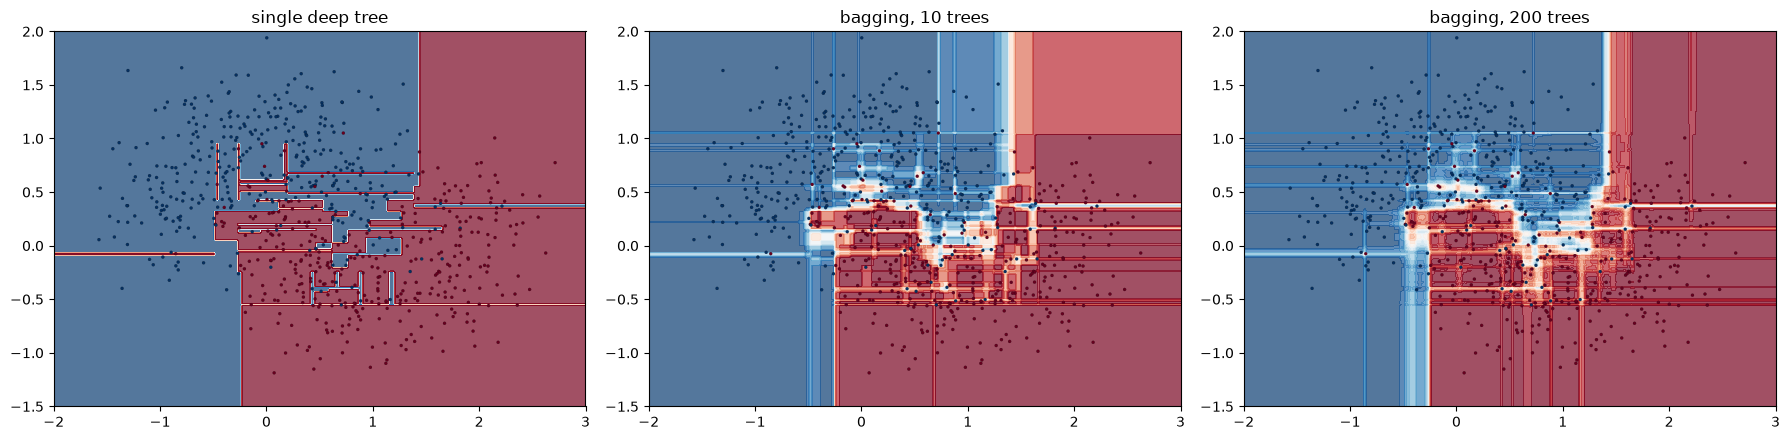

In [5]:
xx, yy = np.meshgrid(np.linspace(-2, 3, 300), np.linspace(-1.5, 2, 300)); grid = np.c_[xx.ravel(), yy.ravel()]
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for ax, (name, m) in zip(axes, [("single deep tree", single), ("bagging, 10 trees", BaggingScratch(lambda: DecisionTreeClassifier(), 10).fit(X_tr, y_tr)),
                                ("bagging, 200 trees", BaggingScratch(lambda: DecisionTreeClassifier(), 200).fit(X_tr, y_tr))]):
    ax.contourf(xx, yy, m.predict_proba(grid)[:, 1].reshape(xx.shape), levels=20, cmap="RdBu_r", alpha=0.7)
    ax.scatter(*X_tr.T, c=y_tr, cmap="RdBu_r", s=5, edgecolor="k", lw=0.1); ax.set_title(name)
plt.tight_layout(); plt.show()

## **4. scikit-learn's BaggingClassifier and OOB Evaluation**
On average each sample is **out-of-bag** for ~37% of the models. Predicting each sample only with models that did not see it gives a free validation estimate, the **OOB score**, without a separate validation set.

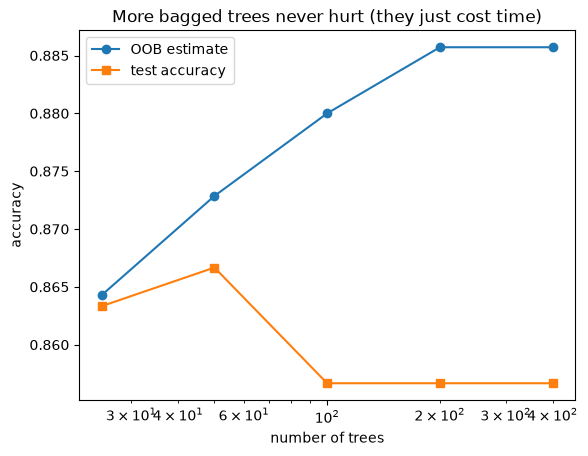

In [6]:
from sklearn.ensemble import BaggingClassifier
n_list = [25, 50, 100, 200, 400]          # with fewer trees some samples are never out-of-bag
oob, test = [], []
for n_est in n_list:
    b = BaggingClassifier(DecisionTreeClassifier(), n_estimators=n_est, oob_score=True, random_state=0, n_jobs=-1).fit(X_tr, y_tr)
    oob.append(b.oob_score_); test.append(b.score(X_te, y_te))
plt.plot(n_list, oob, "o-", label="OOB estimate"); plt.plot(n_list, test, "s-", label="test accuracy")
plt.xscale("log"); plt.xlabel("number of trees"); plt.ylabel("accuracy"); plt.legend(); plt.title("More bagged trees never hurt (they just cost time)"); plt.show()

## **5. Random Subspaces and Random Patches**
Instead of (or in addition to) sampling rows, sample **features**:
- **Random subspaces** (Ho, 1998): each model sees a random subset of features.
- **Random patches**: random rows **and** random features.
This increases diversity, especially with many correlated features. It is one of the two ingredients of Random Forests (Day 36).

In [7]:
from sklearn.datasets import make_classification
Xh, yh = make_classification(2000, 60, n_informative=10, n_redundant=30, random_state=0)
configs = {"bagging (rows)": dict(max_samples=1.0, max_features=1.0, bootstrap=True),
           "random subspaces (features)": dict(max_samples=1.0, max_features=0.3, bootstrap=False),
           "random patches (rows + features)": dict(max_samples=0.7, max_features=0.3, bootstrap=True)}
print(f"single tree: {cross_val_score(DecisionTreeClassifier(random_state=0), Xh, yh, cv=5).mean():.3f}")
for name, kw in configs.items():
    print(f"{name:<34} {cross_val_score(BaggingClassifier(DecisionTreeClassifier(), n_estimators=200, random_state=0, n_jobs=-1, **kw), Xh, yh, cv=5).mean():.3f}")

single tree: 0.809


bagging (rows)                     0.899


random subspaces (features)        0.915


random patches (rows + features)   0.903


# **Part 2: Going Deeper - What Bagging Does to Bias and Variance**

We measure bias^2 and variance (Day 16) of a single regression tree vs a bagged ensemble, and of a stable model (linear regression), over many training sets.

In [8]:
from sklearn.linear_model import LinearRegression
def make_reg(n, seed):
    r = np.random.default_rng(seed); x = r.uniform(0, 1, n); return x[:, None], np.sin(2 * np.pi * x) + r.normal(0, 0.3, n)

xg = np.linspace(0.02, 0.98, 60)[:, None]; f_true = np.sin(2 * np.pi * xg.ravel())
def bias_var(factory, B=100):
    P = np.array([factory().fit(*make_reg(80, s)).predict(xg) for s in range(B)])
    return np.mean((P.mean(0) - f_true) ** 2), np.mean(P.var(0))

from sklearn.ensemble import BaggingRegressor
rows = {}
for name, f in {"deep tree": lambda: DecisionTreeRegressor(),
                "bagged deep trees": lambda: BaggingRegressor(DecisionTreeRegressor(), n_estimators=50, random_state=0),
                "linear regression": lambda: LinearRegression(),
                "bagged linear regression": lambda: BaggingRegressor(LinearRegression(), n_estimators=50, random_state=0)}.items():
    b2, v = bias_var(f); rows[name] = {"bias^2": b2, "variance": v, "total (excl. noise)": b2 + v}
pd.DataFrame(rows).T.round(4)

,bias^2,variance,total (excl. noise)
deep tree,0.0010,0.0885,0.0895
bagged deep trees,0.0005,0.0430,0.0435
linear regression,0.1804,0.0092,0.1895
bagged linear regression,0.1800,0.0094,0.1895


- Bagging **slashes the variance** of deep trees and leaves bias almost unchanged.
- Bagging a **stable, high-bias** model (linear regression) does nothing useful. Bias is reduced by **boosting** (Day 37).

## **Practice Problems**
1. Use a `VotingClassifier` with `weights=[1, 2, 1, 1, 0]`. Does weighting the SVM more help?
2. In `BaggingScratch`, record the OOB accuracy as trees are added and plot it.
3. Bag `KNeighborsClassifier(1)`. Does it improve as much as bagged trees? Why (kNN-1 is unstable, but how sensitive is it to bootstrap resampling)?
4. *(Advanced)* Measure the correlation between the predictions of two bagged trees and between two random-subspace trees on `Xh`. Which ensemble is more diverse?

weighted soft vote: 0.887


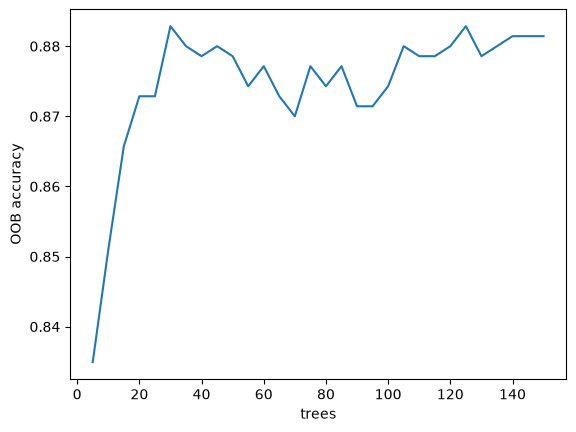

1-NN: 0.843 | bagged 1-NN: 0.843


mean pairwise correlation: bagging 0.733 | random subspaces 1.000


In [9]:
# Solution 1
print("weighted soft vote:", cross_val_score(VotingClassifier(members, voting="soft", weights=[1, 2, 1, 1, 0]), X, y, cv=10).mean().round(3))
# Solution 2
b = BaggingScratch(lambda: DecisionTreeClassifier(), 150).fit(X_tr, y_tr)
curve = []
for k in range(5, 151, 5):
    sub = BaggingScratch.__new__(BaggingScratch); sub.models_, sub.oob_masks_, sub.X_, sub.y_ = b.models_[:k], b.oob_masks_[:k], b.X_, b.y_
    curve.append(sub.oob_score())
plt.plot(range(5, 151, 5), curve); plt.xlabel("trees"); plt.ylabel("OOB accuracy"); plt.show()
# Solution 3
print("1-NN:", cross_val_score(KNeighborsClassifier(1), X, y, cv=5).mean().round(3),
      "| bagged 1-NN:", cross_val_score(BaggingClassifier(KNeighborsClassifier(1), 100, random_state=0, n_jobs=-1), X, y, cv=5).mean().round(3))
# Solution 4
def pair_corr(**kw):
    bb = BaggingClassifier(DecisionTreeClassifier(), n_estimators=20, random_state=0, **kw).fit(Xh, yh)
    P = np.array([est.predict_proba(Xh[:, f])[:, 1] for est, f in zip(bb.estimators_, bb.estimators_features_)])
    C = np.corrcoef(P); return C[np.triu_indices(len(P), 1)].mean()
print(f"mean pairwise correlation: bagging {pair_corr():.3f} | random subspaces {pair_corr(max_features=0.3, bootstrap=False):.3f}")

## **Key References**
- Breiman, L. (1996). Bagging predictors. *Machine Learning*, 24(2), 123-140.
- Ho, T. K. (1998). The random subspace method for constructing decision forests. *IEEE TPAMI*, 20(8), 832-844.
- Dietterich, T. G. (2000). Ensemble methods in machine learning. *Multiple Classifier Systems*, LNCS 1857, 1-15.
- Kuncheva, L. I., & Whitaker, C. J. (2003). Measures of diversity in classifier ensembles and their relationship with the ensemble accuracy. *Machine Learning*, 51(2), 181-207.
- Louppe, G., & Geurts, P. (2012). Ensembles on random patches. *ECML PKDD 2012*.